# <center>  **<span style="font-size:80px;">Exploración de los Datos</span>** </center>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os


from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)


sys.path.append(os.path.abspath(os.path.join("..")))
from src.config import Paths
from src.config import DatasetKeys

In [2]:
from src.water2fraud.features.preprocessor import WaterPreprocessor
from src.water2fraud.models.water_segmenter import WaterSegmenter

preprocessor = WaterPreprocessor()

In [3]:
seed = 80
images_path = Path("./AMAEM")
images_path.mkdir(parents=True, exist_ok=True)

# Renombrado

In [4]:
df = pd.read_csv(Paths.DATA / "AMAEM.csv")

In [5]:
df = df.rename(columns={
    "Barrio": DatasetKeys.BARRIO, 
    "Uso": DatasetKeys.USO, 
    "Fecha (aaaa/mm/dd)": DatasetKeys.FECHA,
    "Consumo (litros)": DatasetKeys.CONSUMO,
    "Nº Contratos" : DatasetKeys.NUM_CONTRATOS
})

# Estructura General

In [6]:
df.shape

(5796, 5)

In [7]:
df.dtypes

barrio           str
uso              str
fecha            str
consumo          str
num_contratos    str
dtype: object

In [8]:
df.head()

,barrio,uso,fecha,consumo,num_contratos
0,10-FLORIDA BAJA,COMERCIAL,2022/01/31,"511,019",91
1,10-FLORIDA BAJA,DOMESTICO,2022/01/31,"29,205,005","4,665"
2,10-FLORIDA BAJA,NO DOMESTICO,2022/01/31,"4,362,320",418
3,11-CIUDAD DE ASIS,COMERCIAL,2022/01/31,"1,700,222",87
4,11-CIUDAD DE ASIS,DOMESTICO,2022/01/31,"14,650,197","2,259"


In [9]:
len(df[DatasetKeys.BARRIO].unique())

57

In [10]:
df.isnull().sum()

barrio            0
uso               0
fecha             0
consumo          21
num_contratos    21
dtype: int64

# Manejo de Valores Faltantes

In [11]:
df[df[DatasetKeys.CONSUMO].isna()]

,barrio,uso,fecha,consumo,num_contratos
81,35-VIRGEN DEL CARMEN,COMERCIAL,2022/01/31,NaN,NaN
152,TABARCA,COMERCIAL,2022/01/31,NaN,NaN
242,35-VIRGEN DEL CARMEN,COMERCIAL,2022/02/28,NaN,NaN
313,TABARCA,COMERCIAL,2022/02/28,NaN,NaN
403,35-VIRGEN DEL CARMEN,COMERCIAL,2022/03/31,NaN,NaN
564,35-VIRGEN DEL CARMEN,COMERCIAL,2022/04/30,NaN,NaN
725,35-VIRGEN DEL CARMEN,COMERCIAL,2022/05/31,NaN,NaN
886,35-VIRGEN DEL CARMEN,COMERCIAL,2022/06/30,NaN,NaN
957,TABARCA,COMERCIAL,2022/06/30,NaN,NaN
1279,TABARCA,COMERCIAL,2022/08/31,NaN,NaN


In [12]:
df[df[DatasetKeys.NUM_CONTRATOS].isna()]

,barrio,uso,fecha,consumo,num_contratos
81,35-VIRGEN DEL CARMEN,COMERCIAL,2022/01/31,NaN,NaN
152,TABARCA,COMERCIAL,2022/01/31,NaN,NaN
242,35-VIRGEN DEL CARMEN,COMERCIAL,2022/02/28,NaN,NaN
313,TABARCA,COMERCIAL,2022/02/28,NaN,NaN
403,35-VIRGEN DEL CARMEN,COMERCIAL,2022/03/31,NaN,NaN
564,35-VIRGEN DEL CARMEN,COMERCIAL,2022/04/30,NaN,NaN
725,35-VIRGEN DEL CARMEN,COMERCIAL,2022/05/31,NaN,NaN
886,35-VIRGEN DEL CARMEN,COMERCIAL,2022/06/30,NaN,NaN
957,TABARCA,COMERCIAL,2022/06/30,NaN,NaN
1279,TABARCA,COMERCIAL,2022/08/31,NaN,NaN


A la hora de realizar el procesamiento sobre nuestros datos deberemos tener en cuenta que los siguientes barrios no cuentan con información sobre el contrato con uso Comercial:

- 35-VIRGEN DEL CARMEN
- TABARCA
- REBOLLEDO

In [13]:
# Eliminamos todos los nulos (al no representar gran parte de nuestros datos)
df = df.dropna()

# Conversión de datos

In [14]:
df = preprocessor._process_dataframe(df)
df.dtypes

barrio                      str
uso                         str
fecha            datetime64[us]
consumo                   int64
num_contratos             int64
consumo_ratio           float64
mes                       int32
es_finde                   bool
dtype: object

In [15]:
df

,barrio,uso,fecha,consumo,num_contratos,consumo_ratio,mes,es_finde
0,10-FLORIDA BAJA,COMERCIAL,2022-01-31,511019,91,5615.593407,1,False
1,10-FLORIDA BAJA,DOMESTICO,2022-01-31,29205005,4665,6260.451233,1,False
2,10-FLORIDA BAJA,NO DOMESTICO,2022-01-31,4362320,418,10436.172249,1,False
3,11-CIUDAD DE ASIS,COMERCIAL,2022-01-31,1700222,87,19542.781609,1,False
4,11-CIUDAD DE ASIS,DOMESTICO,2022-01-31,14650197,2259,6485.257636,1,False
...,...,...,...,...,...,...,...,...
5791,VERDEGAS,DOMESTICO,2024-12-31,1819211,220,8269.140909,12,False
5792,VERDEGAS,NO DOMESTICO,2024-12-31,63675,5,12735.000000,12,False
5793,VILLAFRANQUEZA,COMERCIAL,2024-12-31,3699499,10,369949.900000,12,False
5794,VILLAFRANQUEZA,DOMESTICO,2024-12-31,11106866,1471,7550.554725,12,False


# Tratamiento de Outliers

In [16]:
feature, labels_col = DatasetKeys.CONTRATO_RATIO, DatasetKeys.USO
labels = df[labels_col].unique()
colors = dict(zip(labels, sns.color_palette("viridis", len(labels))))

In [17]:
def feature_analysis(feature):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(4, 2, figsize=(16, 24))

    for i, ax_row in enumerate(axes):
        is_glb = (i == 3)
        subset = df if is_glb else df[df[labels_col] == labels[i]]
        title, color = ("VISTA GLOBAL", None) if is_glb else (labels[i], colors[labels[i]])
        
        # --- CÁLCULO DE LÍMITES CON RECORTE ---
        q1, q3 = subset[feature].quantile(0.25), subset[feature].quantile(0.75)
        iqr = q3 - q1
        
        # Aplicamos max(0, ...) para que el límite inferior nunca sea negativo
        l_inf = max(0, q1 - 1.5 * iqr)
        l_sup = q3 + 1.5 * iqr
        
        # Params comunes
        strip_kwargs = {"hue": labels_col, "palette": colors} if is_glb else {"color": color}
        hist_kwargs = {"hue": labels_col, "palette": colors, "common_norm": False} if is_glb else {"color": color}

        # COLUMNA 0: Boxplot + Strips
        sns.boxplot(data=subset, x=feature, ax=ax_row[0], color=color or "#f5f5f5", boxprops={"alpha": 0.3}, fliersize=0)
        sns.stripplot(data=subset, x=feature, ax=ax_row[0], alpha=0.3, jitter=0.3, s=5, **strip_kwargs)
        
        # Outliers
        outliers = subset[subset[feature] > l_sup]
        ax_row[0].scatter(outliers[feature], np.zeros(len(outliers)), edgecolor="black", facecolor="none", linewidth=0.6, s=30, zorder=5)
        if is_glb: ax_row[0].get_legend().remove()

        # COLUMNA 1: Histograma
        sns.histplot(data=subset, x=feature, kde=True, ax=ax_row[1], alpha=0.4, bins=50, **hist_kwargs)
        
        # Líneas de umbral
        ax_row[1].axvline(l_sup, color="red", linestyle="--", alpha=0.6, label=f'L.Sup: {l_sup:.1f}')
        if l_inf > 0:
            ax_row[1].axvline(l_inf, color="red", linestyle="--", alpha=0.6, label=f'L.Inf: {l_inf:.1f}')

        # --- AJUSTE DE EJES X (Limpio de negativos) ---
        for ax in ax_row:
            # Forzamos que el eje X empiece en 0
            ax.set_xlim(left=0) 
            
            # Ticks: Solo valores positivos y relevantes
            current_ticks = [t for t in ax.get_xticks() if t >= 0]
            # Añadimos los límites calculados y limpiamos duplicados
            custom_ticks = sorted(list(set(current_ticks + [l_inf, l_sup])))
            ax.set_xticks(custom_ticks)
            ax.tick_params(axis='x', rotation=45)

        # Títulos
        for j, suffix in enumerate(["Dispersión", "Distribución"]):
            ax_row[j].set_title(f"{title} | {suffix}", weight="bold")

    plt.suptitle(f"Análisis Diagnóstico: '{feature}'", fontsize=22, weight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(images_path / f"analisis_{feature}")

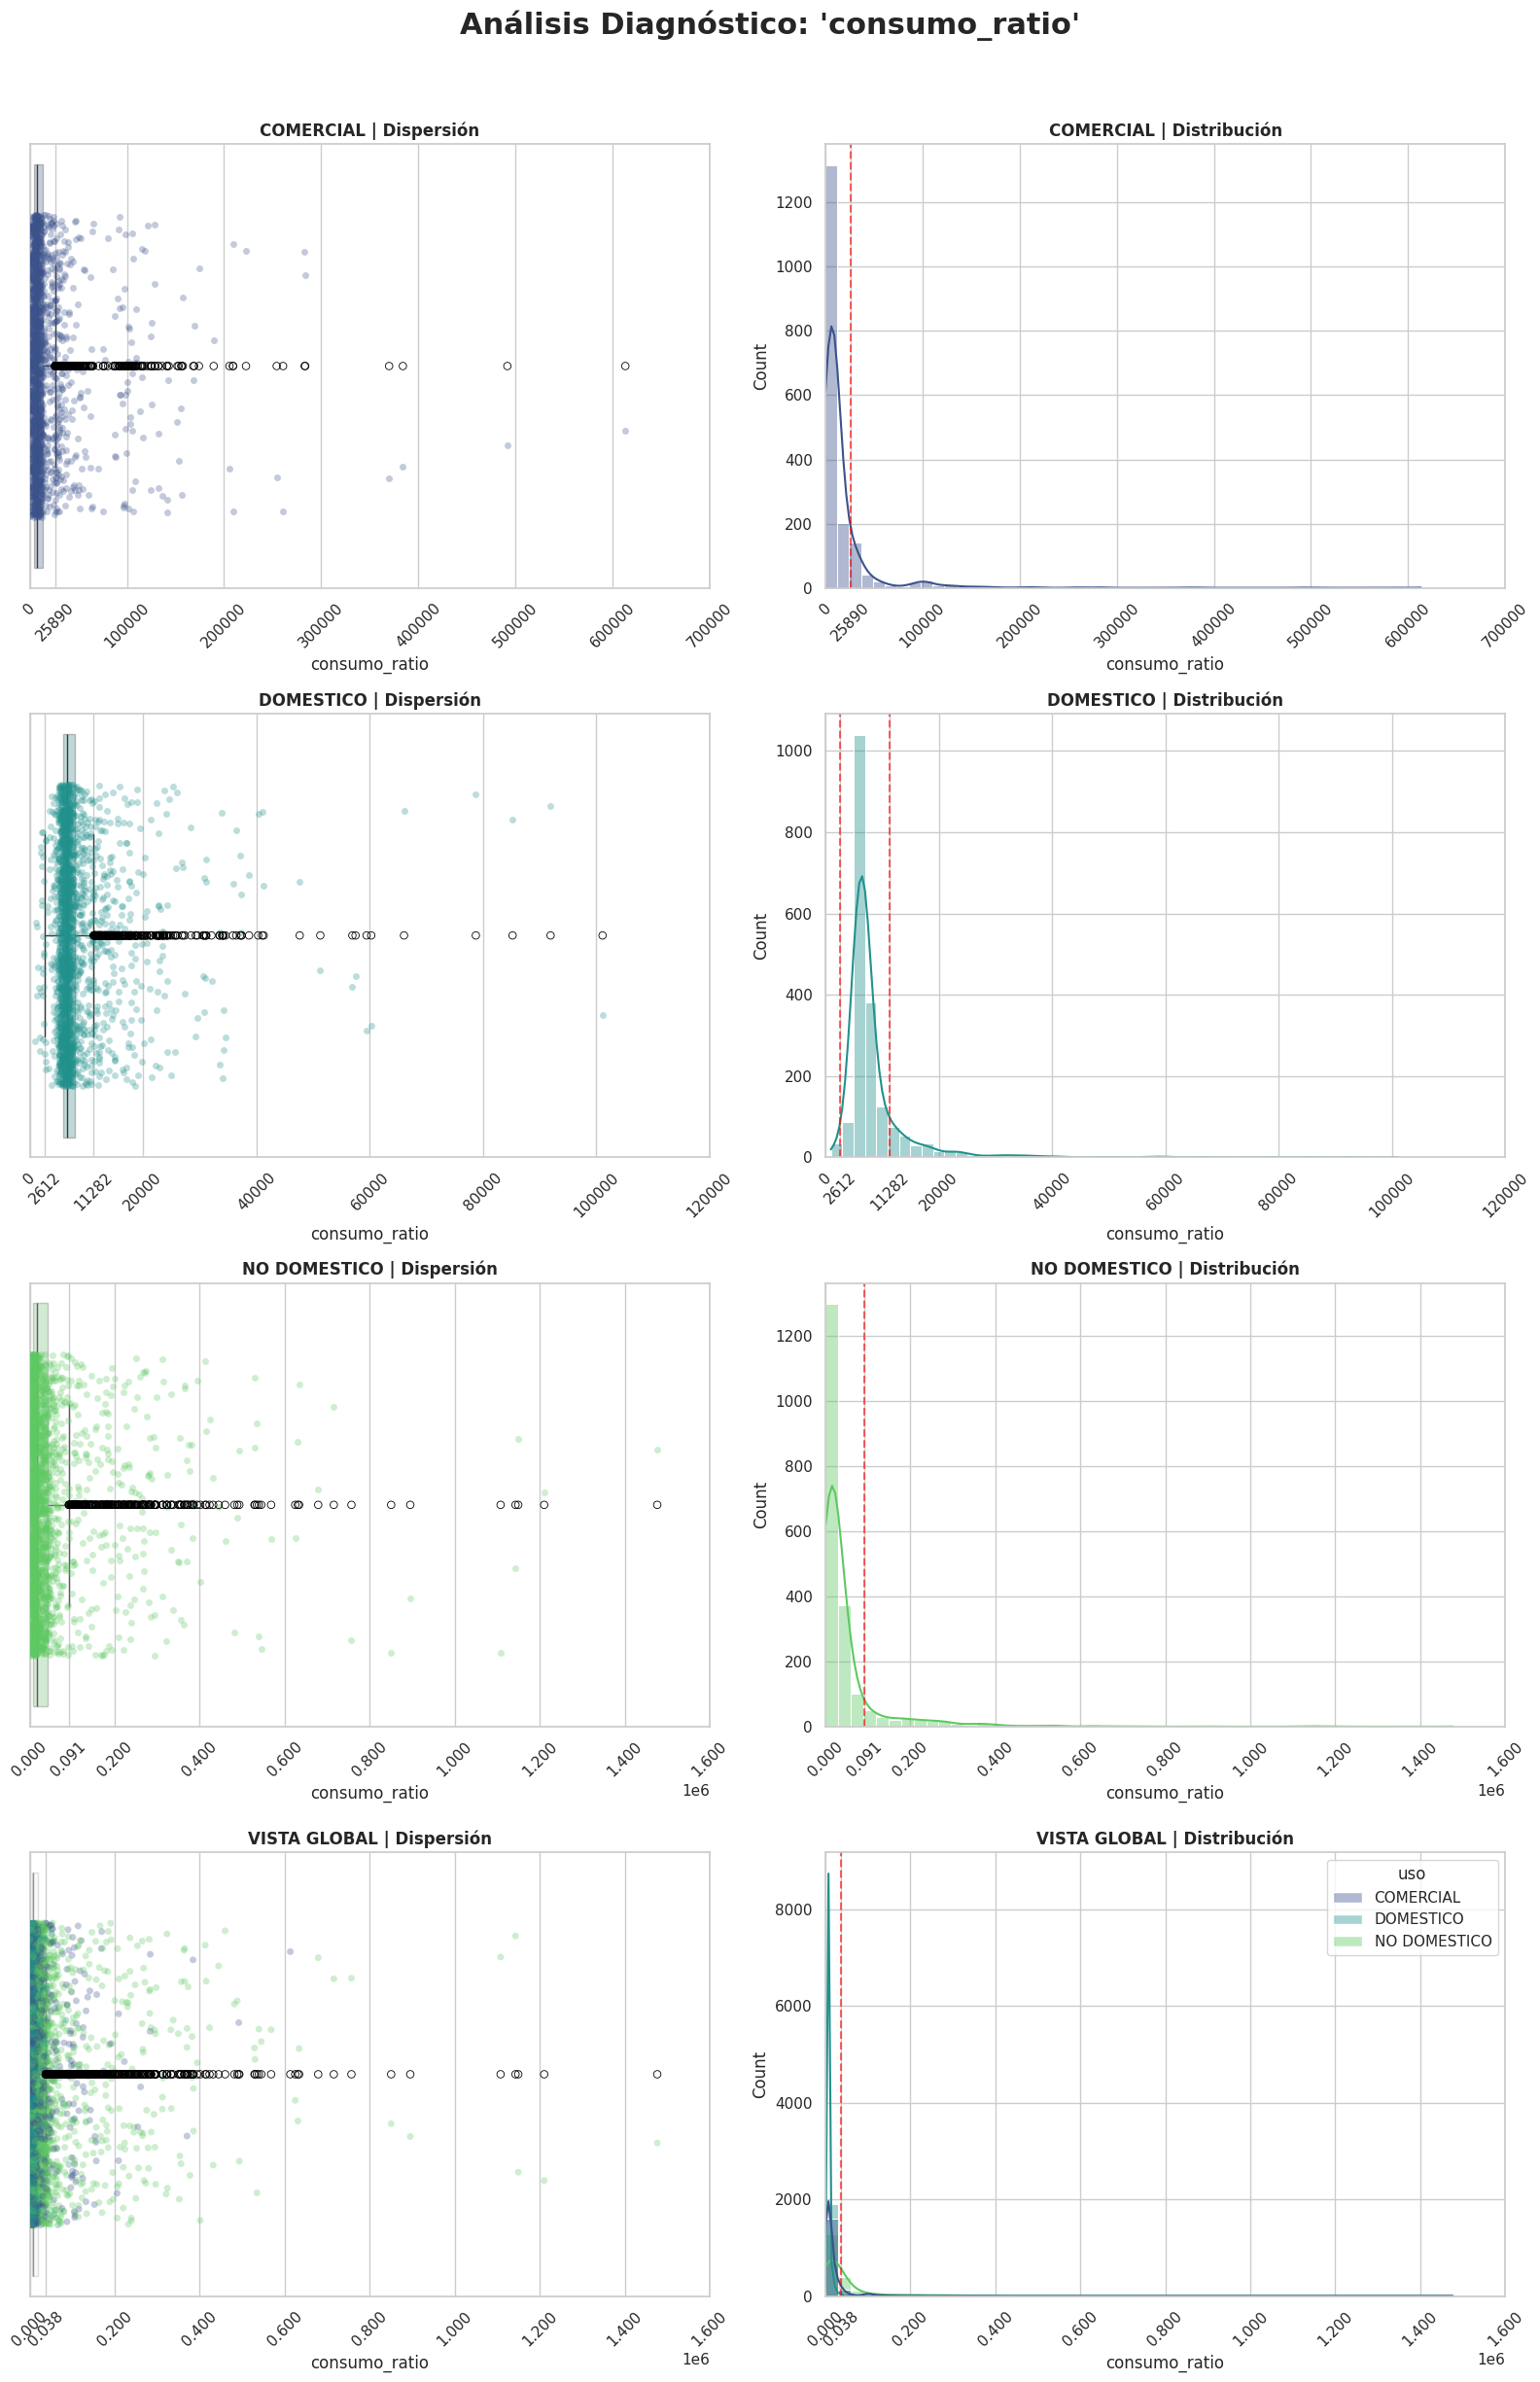

In [18]:
feature_analysis(DatasetKeys.CONTRATO_RATIO)

In [19]:
def get_outliers_report(df, feature, labels_col):
    """
    Identifica y devuelve las filas que superan el límite superior de IQR.
    """
    report_list = []
    for label in labels:
        subset = df[df[labels_col] == label]
        q1, q3 = subset[feature].quantile([0.25, 0.75])
        l_sup = q3 + 1.5 * (q3 - q1)
        
        outliers_subset = subset[subset[feature] > l_sup].copy()
        outliers_subset["Threshold"] = l_sup
        report_list.append(outliers_subset)

    full_report = pd.concat(report_list).drop_duplicates(subset=df.columns)
    return full_report.sort_values(by=feature, ascending=False)

## Análisis Outliers

Podemos ver que mayoritariamente, los valores con ***alto ratio de consumo*** corresponden con contratos de tipo **NO DOMESTICO**. El motivo se debe a que barrios como **LA ALCORAYA** constan de zonas de regadío. Podríamos tener en cuenta que este suceso a la hora de diseñar el sistema de créditos **Water2Creds**.

In [20]:
outliers_df = get_outliers_report(df, DatasetKeys.CONTRATO_RATIO, DatasetKeys.USO)

print(f"Se han detectado {len(outliers_df)} filas anómalas.")
outliers_df.head(10) # Ver los 10 casos más extremos

Se han detectado 775 filas anómalas.


,barrio,uso,fecha,consumo,num_contratos,consumo_ratio,mes,es_finde,Threshold
4162,LA ALCORAYA,NO DOMESTICO,2024-02-29,2953148,2,1476574.0,2,False,91475.270818
2713,LA ALCORAYA,NO DOMESTICO,2023-05-31,2421074,2,1210537.0,5,False,91475.270818
3035,LA ALCORAYA,NO DOMESTICO,2023-07-31,2298933,2,1149466.5,7,False,91475.270818
3196,LA ALCORAYA,NO DOMESTICO,2023-08-31,2286062,2,1143031.0,8,False,91475.270818
3518,LA ALCORAYA,NO DOMESTICO,2023-10-31,2215893,2,1107946.5,10,False,91475.270818
4001,LA ALCORAYA,NO DOMESTICO,2024-01-31,1790760,2,895380.0,1,False,91475.270818
942,LA ALCORAYA,NO DOMESTICO,2022-06-30,1700750,2,850375.0,6,False,91475.270818
2552,LA ALCORAYA,NO DOMESTICO,2023-04-30,1513832,2,756916.0,4,True,91475.270818
2874,LA ALCORAYA,NO DOMESTICO,2023-06-30,1430895,2,715447.5,6,False,91475.270818
3357,LA ALCORAYA,NO DOMESTICO,2023-09-30,1357420,2,678710.0,9,True,91475.270818


Sorprende observar que $\frac{14}{57} \approx 24.56 \%$ de nuestros barrios contienen ratios inusuales en contratos **DOMESTICOS**. Además, estos valores suelen alcanzar sus máximos cuando se tratan de meses calurosos correspondiente a los meses $6$, $7$ y $8$ (Junio, Julio, Agosto).

Podemos analizar el comportamiento del barrio **TABARCA**. Ya que sabemos que, *a priori*, tendrá más probabilidad en viviendas turísticas ilegales comparadas con el resto de barrios.

In [21]:
outliers_domestico = outliers_df[outliers_df[DatasetKeys.USO] == "DOMESTICO"] \
                                     .sort_values(DatasetKeys.CONTRATO_RATIO, ascending=False) \
                                     .groupby(DatasetKeys.BARRIO) \
                                     .head(1)

outliers_domestico.sort_values(by=DatasetKeys.CONTRATO_RATIO, ascending=False)

,barrio,uso,fecha,consumo,num_contratos,consumo_ratio,mes,es_finde,Threshold
3173,56-DISPERSOS,DOMESTICO,2023-08-31,303278,3,101092.666667,8,False,11282.033983
1268,MONNEGRE,DOMESTICO,2022-08-31,5001915,105,47637.285714,8,False,11282.033983
1272,PDA VALLONGA,DOMESTICO,2022-08-31,4182745,147,28454.047619,8,False,11282.033983
3032,FONTCALENT,DOMESTICO,2023-07-31,8519736,331,25739.383686,7,False,11282.033983
1109,MORALET,DOMESTICO,2022-07-31,19395449,797,24335.569636,7,True,11282.033983
1266,LA CAÑADA,DOMESTICO,2022-08-31,15964668,709,22517.162200,8,False,11282.033983
3209,SANTA FAZ,DOMESTICO,2023-08-31,8074217,374,21588.815508,8,False,11282.033983
1102,LA ALCORAYA,DOMESTICO,2022-07-31,3967026,211,18801.071090,7,True,11282.033983
1122,VERDEGAS,DOMESTICO,2022-07-31,3854823,206,18712.733010,7,True,11282.033983
4962,BACAROT,DOMESTICO,2024-07-31,4431107,245,18086.151020,7,False,11282.033983


# Codificación de Variables

In [22]:
dummies = pd.get_dummies(df[DatasetKeys.USO], prefix=DatasetKeys.USO, dtype=int)
df = pd.concat([df, dummies], axis=1)

df.tail()

,barrio,uso,fecha,consumo,num_contratos,consumo_ratio,mes,es_finde,uso_COMERCIAL,uso_DOMESTICO,uso_NO DOMESTICO
5791,VERDEGAS,DOMESTICO,2024-12-31,1819211,220,8269.140909,12,False,0,1,0
5792,VERDEGAS,NO DOMESTICO,2024-12-31,63675,5,12735.000000,12,False,0,0,1
5793,VILLAFRANQUEZA,COMERCIAL,2024-12-31,3699499,10,369949.900000,12,False,1,0,0
5794,VILLAFRANQUEZA,DOMESTICO,2024-12-31,11106866,1471,7550.554725,12,False,0,1,0
5795,VILLAFRANQUEZA,NO DOMESTICO,2024-12-31,8091294,115,70359.078261,12,False,0,0,1


# Estadística Descriptiva

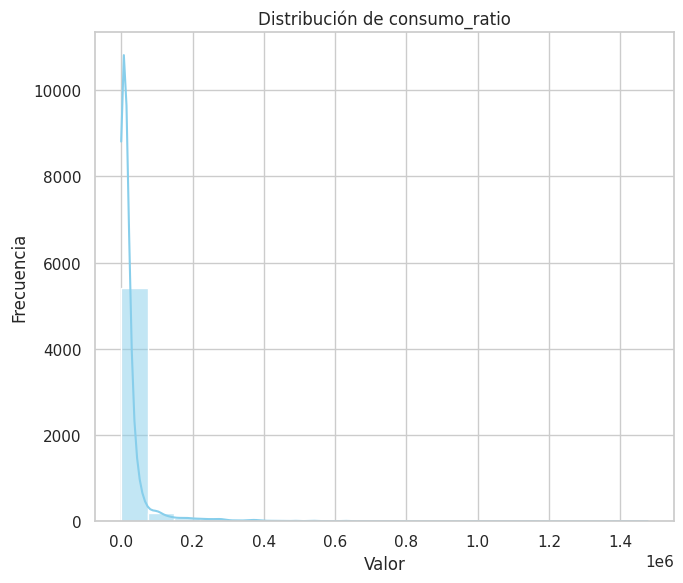

In [23]:
features = [DatasetKeys.CONTRATO_RATIO]

cols = min(len(features), 2)
rows = (len(features) + cols - 1) // cols 

fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 6), squeeze=False)
axes = axes.flatten()

colors = ["skyblue", "lightgreen", "salmon", "plum"]
for idx, feature in enumerate(features):
    if idx < len(features):
        feature = features[idx]
        ax = axes[idx]
        
        sns.histplot(data=df, x=feature, kde=True, bins=20, ax=ax, color=colors[idx % 4])
        ax.set_title(f"Distribución de {feature}")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Frecuencia")
    else:
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(images_path / "distribuciones_univariadas.png", dpi=300, bbox_inches="tight")

# Relaciones Bivariadas

In [24]:
new_features = [DatasetKeys.CONTRATO_RATIO,
                DatasetKeys.USO_COMERCIAL, DatasetKeys.USO_DOMESTICO, DatasetKeys.USO_NO_DOMESTICO]

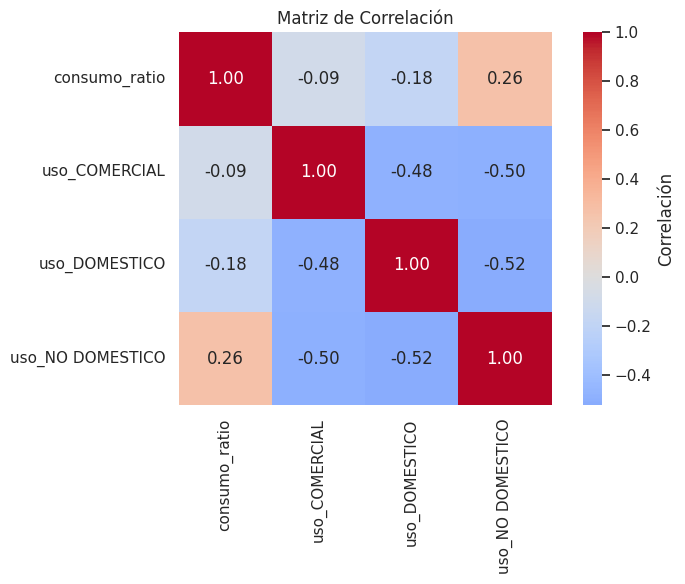

In [25]:
corr_matrix = df[new_features].corr()

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, ax=ax, cbar_kws={"label": "Correlación"})
ax.set_title("Matriz de Correlación")
plt.tight_layout()
plt.savefig(images_path / "correlacion.png", dpi=300, bbox_inches="tight")


# Scatter Plots

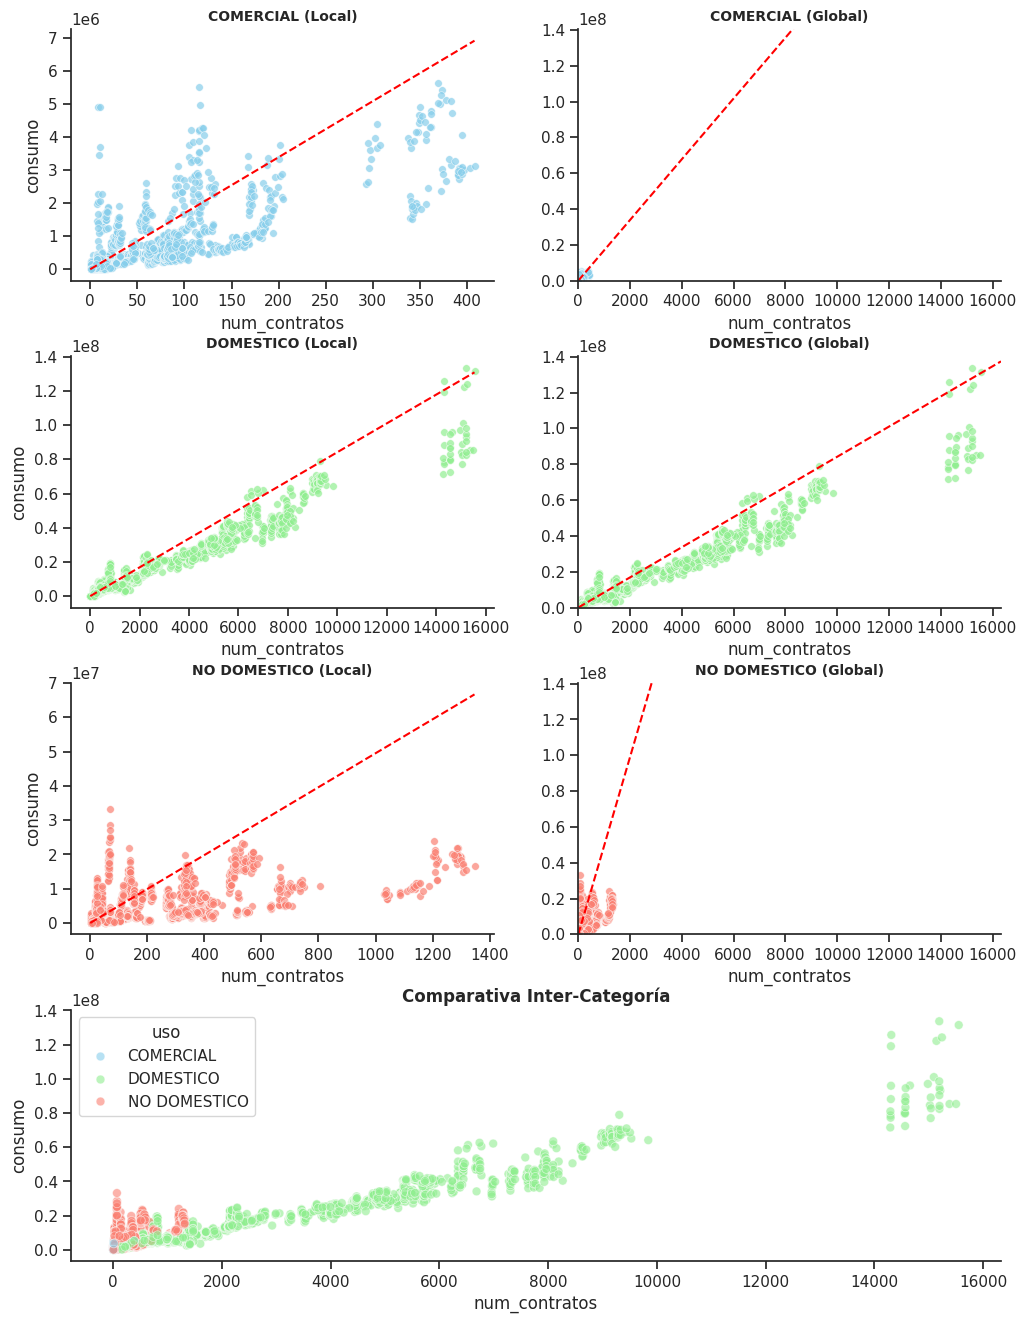

In [26]:
palette_mapping = dict(zip(labels, colors))
sns.set_theme(style="ticks")
fig = plt.figure(figsize=(12, 16))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.2)
lims = {"x": (0, df[DatasetKeys.NUM_CONTRATOS].max() * 1.05), 
        "y": (0, df[DatasetKeys.CONSUMO].max() * 1.05)}


for i, label in enumerate(labels):
    data = df[df[DatasetKeys.USO] == label]
    current_color = colors[i]

    ratio_local = (data[DatasetKeys.CONSUMO] / data[DatasetKeys.NUM_CONTRATOS]).mean()

    for j in range(2):
        ax = fig.add_subplot(gs[i, j])
        
        sns.scatterplot(data=data, x=DatasetKeys.NUM_CONTRATOS, y=DatasetKeys.CONSUMO, 
                        ax=ax, s=30, alpha=0.7, color=current_color)
        
    
        x_max = data[DatasetKeys.NUM_CONTRATOS].max() if j == 0 else lims["x"][1]
        x_vals = np.array([0, x_max])
        y_vals = ratio_local * x_vals
        ax.plot(x_vals, y_vals, color="red", linestyle="--", linewidth=1.5, label=f"Ratio: {ratio_local:.2f}")

        if j == 1: 
            ax.set(xlim=lims["x"], ylim=lims["y"], ylabel="")        
        ax.set_title(f"{label} ({"Global" if j==1 else "Local"})", fontsize=10, weight="bold")

ax_full = fig.add_subplot(gs[3, :])
sns.scatterplot(data=df, x=DatasetKeys.NUM_CONTRATOS, y=DatasetKeys.CONSUMO, 
                hue=DatasetKeys.USO, hue_order=labels,  palette=palette_mapping, ax=ax_full, s=40, alpha=0.6)

ax_full.set_title("Comparativa Inter-Categoría", fontsize=12, weight="bold")
sns.despine()
plt.savefig(images_path / "scatter_plots.png")

# Imbalance y Representatividad

In [27]:
label = DatasetKeys.USO
df[label].value_counts()

uso
NO DOMESTICO    2016
DOMESTICO       1944
COMERCIAL       1815
Name: count, dtype: int64

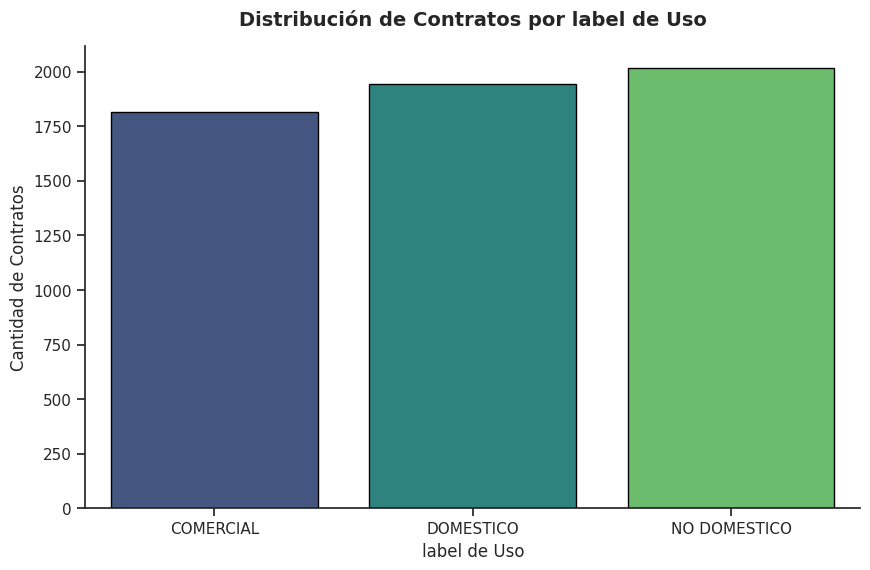

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x=label, palette="viridis", hue=label, ax=ax,edgecolor="black",linewidth=1)
ax.set_title("Distribución de Contratos por label de Uso", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("label de Uso", fontsize=12)
ax.set_ylabel("Cantidad de Contratos", fontsize=12)

sns.despine()
plt.savefig(images_path / "distribucion_balance.png", dpi=300, bbox_inches="tight")

# PCA visualization

In [29]:
df

,barrio,uso,fecha,consumo,num_contratos,consumo_ratio,mes,es_finde,uso_COMERCIAL,uso_DOMESTICO,uso_NO DOMESTICO
0,10-FLORIDA BAJA,COMERCIAL,2022-01-31,511019,91,5615.593407,1,False,1,0,0
1,10-FLORIDA BAJA,DOMESTICO,2022-01-31,29205005,4665,6260.451233,1,False,0,1,0
2,10-FLORIDA BAJA,NO DOMESTICO,2022-01-31,4362320,418,10436.172249,1,False,0,0,1
3,11-CIUDAD DE ASIS,COMERCIAL,2022-01-31,1700222,87,19542.781609,1,False,1,0,0
4,11-CIUDAD DE ASIS,DOMESTICO,2022-01-31,14650197,2259,6485.257636,1,False,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
5791,VERDEGAS,DOMESTICO,2024-12-31,1819211,220,8269.140909,12,False,0,1,0
5792,VERDEGAS,NO DOMESTICO,2024-12-31,63675,5,12735.000000,12,False,0,0,1
5793,VILLAFRANQUEZA,COMERCIAL,2024-12-31,3699499,10,369949.900000,12,False,1,0,0
5794,VILLAFRANQUEZA,DOMESTICO,2024-12-31,11106866,1471,7550.554725,12,False,0,1,0


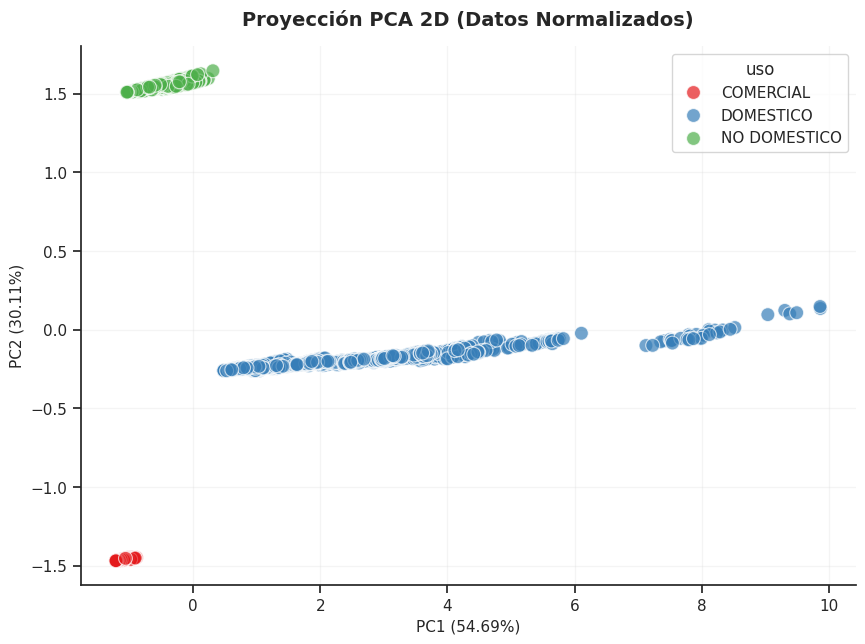

In [30]:
pca_features = [
    DatasetKeys.CONSUMO,
    DatasetKeys.NUM_CONTRATOS,
    DatasetKeys.USO_COMERCIAL,
    DatasetKeys.USO_DOMESTICO,
    DatasetKeys.USO_NO_DOMESTICO,
]

# Procesamiento (Escalado + PCA)
X_scaled = StandardScaler().fit_transform(df[pca_features])
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Creación del DataFrame temporal para Seaborn
df_pca = pd.DataFrame(data=components, columns=["PC1", "PC2"])
df_pca[DatasetKeys.USO] = df[DatasetKeys.USO].values

# Visualización
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 7))

ax = sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue=DatasetKeys.USO, 
    palette="Set1", s=100, alpha=0.7, edgecolor="w"
)

# Etiquetas dinámicas usando los ratios de varianza
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
ax.set_title("Proyección PCA 2D (Datos Normalizados)", fontsize=14, weight="bold", pad=15)

sns.despine()
plt.grid(True, alpha=0.2)
plt.savefig(images_path / "pca_visualization.png", dpi=300, bbox_inches="tight")